In [73]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (IAI_TO_IMAGE_CLASSES, 
                                          aluminium_regions, 
                                          path_input_data,
                                          models_output_dict,
                                          REGION_TO_CLASS_DICT)

In [74]:
# Aluminium
aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                       image_mat_available = True, start_year = 1998, end_year = 2024
                       )

# removed outlier reginos so they are not represented in the global fit
all_regions = ['Africa',
        'Estimated Unreported to IAI', 
        'Gulf Cooperation Council',
        'North America', 
        'Russia & Eastern Europe', 
        'South America',
        'Western & Central Europe']


low_steady = ['Russia & Eastern Europe',
              'Western & Central Europe']

north_america = ['North America']

europe = ['Western & Central Europe']

# own category because fitting otherwise somehow not possible
china = ['China (Estimated)']

# will be fitted to global curve or according to IMAGE Mat with some additions
outlier = ['Oceania']
asia = ['Asia (ex China)']

aluminium_regions = {
    'low_steady' : low_steady,
    'all_regions' : all_regions,
    'china' : china,
    'north_america' : north_america
}

aluminium.data_grouped_regions(regions_grouping = aluminium_regions) 

In [88]:
aluminium.historic_consumption_data

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,6.264801e+05,NaN,NaN,NaN,NaN,2.266968e+06,NaN,NaN,4728000.0
1989,NaN,5.223609e+05,NaN,NaN,1.333230e+03,6.787897e+06,2.714370e+06,1.075250e+05,NaN,4840000.0
1990,6.018660e+05,3.435971e+05,NaN,NaN,1.729161e+03,6.891520e+06,2.728864e+06,1.259970e+05,NaN,5071000.0
1991,6.118305e+05,6.191659e+05,7.865230e+02,NaN,2.519060e+05,7.438025e+06,2.761736e+06,6.397000e+04,NaN,5236000.0
1992,6.086064e+05,7.972590e+05,NaN,4.689961e+06,2.524190e+05,7.105333e+06,2.688783e+06,7.864901e+04,NaN,5346000.0
1993,6.076788e+05,5.913259e+05,NaN,4.738436e+06,2.760718e+05,6.243607e+06,2.990291e+06,NaN,NaN,5376000.0
1994,5.732989e+05,6.325063e+05,NaN,3.989005e+06,NaN,5.176989e+06,2.824821e+06,2.668526e+05,NaN,5364000.0
1995,6.906843e+05,2.960242e+05,NaN,2.362097e+06,6.387243e+04,5.748263e+06,2.813324e+06,4.773458e+04,NaN,5648000.0
1996,1.148404e+06,3.865528e+05,NaN,2.216125e+06,4.868501e+04,6.105438e+06,3.022516e+06,6.058961e+06,NaN,5601000.0
1997,1.258448e+06,4.942532e+05,NaN,1.749081e+06,3.714252e+03,5.918598e+06,3.289635e+06,6.575495e+06,NaN,5788000.0


In [75]:
aluminium.sum_IMAGE_drivers_regions(IAI_TO_IMAGE_CLASSES)
aluminium.match_MAT_data_to_regions_year(match_external_regions=True)
aluminium.calculate_historic_other_fraction()

In [76]:
# Deal with negative values in other fraction BEFORE recalculation of other fraction consumption

# 1) Africa: for all negative values: assumption that apparent MAT is 60% of total consumption (mean until 2017)
# Share of IAMGE MAT data to total consumption
share = (aluminium.image_mat_material_regions.loc[:2017]/aluminium.historic_consumption_data.loc[:2017]*100).mean()
# starting at 2017 (when negative values start):
aluminium.image_mat_material_regions.loc[2017:, 'Africa'] = aluminium.historic_consumption_data.loc[2017:, 'Africa'] * share['Africa'] / 100

# 4) North America
# problem starts at 2015, so take share mean of IMAGE Mat data before that and apply it to 2015-2024
share_na = (aluminium.image_mat_material_regions.loc[:2015]/aluminium.historic_consumption_data.loc[:2015]*100).mean()
aluminium.image_mat_material_regions.loc[:, 'North America'] = aluminium.historic_consumption_data.loc[:, 'North America'] * share_na['North America'] / 100

# 6) South America: assume that share of Mat until 2010 is correct and that apparent consumption needs to be adjusted accordingly 
share_sa = (aluminium.image_mat_material_regions.loc[:2010, 'South America'] / aluminium.historic_consumption_data.loc[:2010, 'South America']).mean()
aluminium.historic_consumption_data.loc[:, 'South America'] = aluminium.image_mat_material_regions.loc[:, 'South America'] / share_sa

# Deal with negative values in other fraction AFTER recalculation of other fraction consumption
# redo calculation of historic other fraction consumption 
aluminium.calculate_historic_other_fraction()

# 2) rest of Asia: 
# per capita consmption of total data is too low compared to other regions, so we assume that IMAGE Mat is correct
# --> will be fitted to global curve 
# 3) Estimated Unreported to IAI: assume that IMAGE Mat is correct (these are mostly IMAGE region 6 regions)
# Most are small island territories, overseas territories or constituent countries mainly linked to France
# --> will be fitted to global curve 

# 5) Gulf Cooperation Council: remove negative values to nan, no problems in more recent years
# & Finally check the whole dataframe for single negative values and make them NaN
aluminium.historic_other_fraction_consumption[aluminium.historic_other_fraction_consumption < 0] = np.nan

In [77]:
# Fit models

aluminium.calculate_regressors(aluminium.historic_other_fraction_consumption)

aluminium.fit_models(best_rmse_models= {
    'low_steady' : 'gompertz model',
    'all_regions' : 'gompertz model',
    'china' : 'gompertz model',
    'north_america' : 'gompertz model'})

# add regions to regions model match that are not in there yet becaused they are fitted to the global average
for key in IAI_TO_IMAGE_CLASSES.keys():
    if key not in aluminium.region_model_match:
        aluminium.region_model_match[key] = aluminium.model_groups.get("all_regions")[6]

low_steady
all_regions
china
north_america


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y, maxfev=5000) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y, maxfev=5000) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y, maxfev=5000) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:2

In [78]:
# Projections
aluminium.project_on_total(list(IAI_TO_IMAGE_CLASSES.keys()))

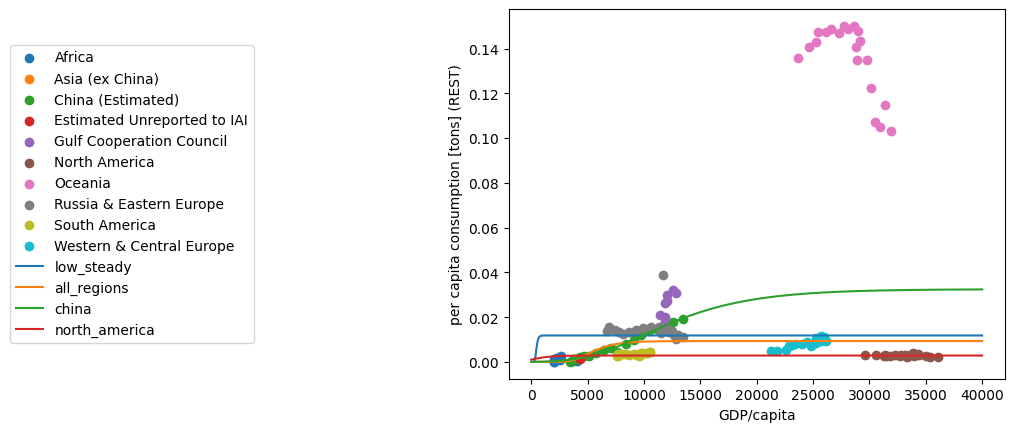

In [79]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

color_dict_fits = {
    'low_steady' : '#1f77b4',  # blue
    'all_regions' : '#ff7f0e',  # orange
    'china' : '#2ca02c',  # green
    'north_america' : '#d62728',  # red
    'europe' : '#9467bd'  # purple

}


# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in aluminium.cons_capita.columns:
    ax.scatter(aluminium.gdp_pc[region], 
               aluminium.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
    
for grouping in aluminium_regions.keys():
    model = aluminium.model_groups[grouping][models_output_dict[aluminium.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'right', bbox_to_anchor=(-0.5, 0.5))

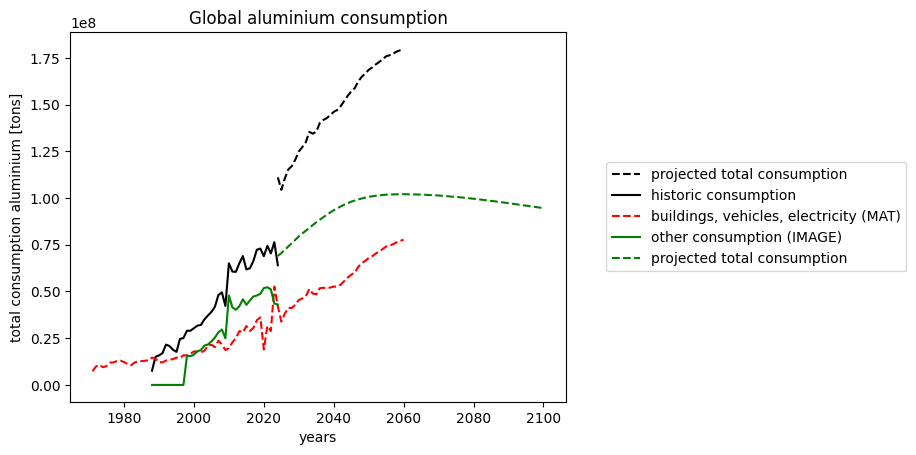

In [87]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(aluminium.projection_per_region_total.sum(axis = 1) + aluminium.image_mat_data.sum(axis = 1).loc[2024:] - aluminium.projection_per_region_total["Asia (ex China)"], 
        linestyle = '--', color = 'black', label = 'projected total consumption')

ax.plot(aluminium.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(aluminium.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.plot(aluminium.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(aluminium.projection_per_region_total.loc[2024: ].sum(axis = 1) - aluminium.projection_per_region_total["Asia (ex China)"],
        linestyle = '--', color = 'green', label = 'projected total consumption')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'right', bbox_to_anchor=(1.7, 0.5))

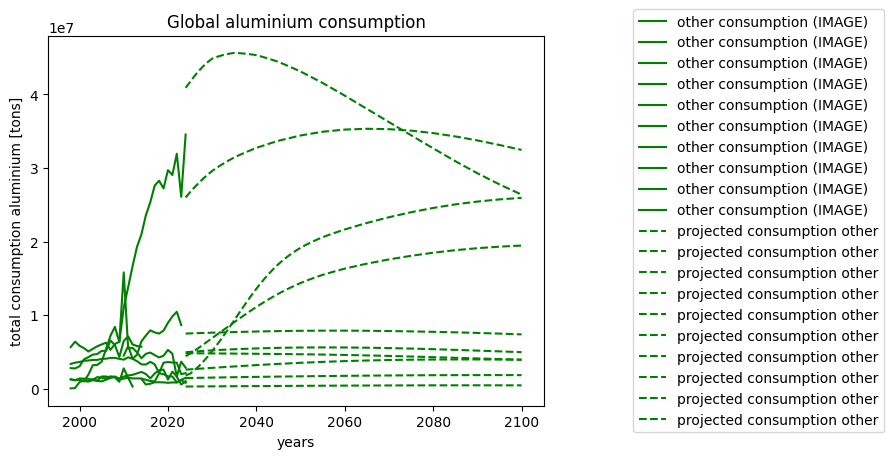

In [84]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

# ax.plot(aluminium.projection_per_region_total + aluminium.image_mat_data.loc[2024:], 
#         linestyle = '--', color = 'black', label = 'projected total consumption')

# ax.plot(aluminium.historic_consumption_data.sum(axis = 1),
#         linestyle = '-', color = 'black', label = 'historic consumption')  

# ax.plot(aluminium.image_mat_data.loc[1971:],
#         linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.plot(aluminium.historic_other_fraction_consumption,
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(aluminium.projection_per_region_total.loc[2024: ],
        linestyle = '--', color = 'green', label = 'projected consumption other')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'right', bbox_to_anchor=(1.7, 0.5))

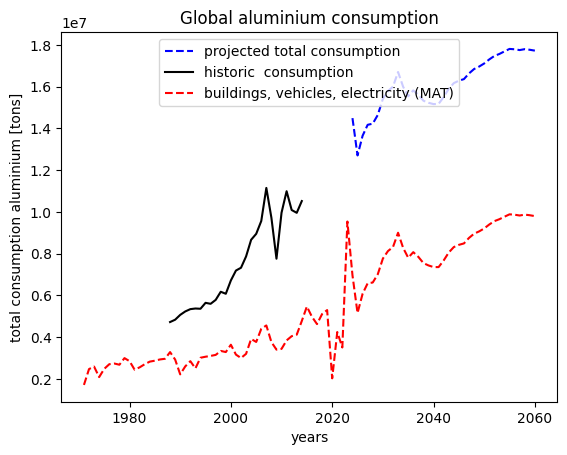

In [82]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

region = 'Western & Central Europe'



ax.plot(aluminium.projection_per_region_total[region].loc[2024:, ] + aluminium.image_mat_material_regions_total[region].loc[2024:, ],
linestyle = '--', color = 'blue', label = 'projected total consumption')

ax.plot(aluminium.historic_consumption_data[region],
        linestyle = '-', color = 'black', label = 'historic  consumption')  

ax.plot(aluminium.image_mat_material_regions_total[region].loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'upper center')

In [83]:
# distribute regino model match to all regions

IMAGE_region_model_match = {}

for groups in aluminium.region_model_match.keys():
    for region in IAI_TO_IMAGE_CLASSES[groups]:
        IMAGE_region_model_match[region] = aluminium.region_model_match[groups]


aluminium.region_model_match = IMAGE_region_model_match